# Day 1 — 05. Remote sensing and discussion

**Instructor:** Efraín Padilla — DLR IMF-ASP

**Estimated duration:** approximately 20 minutes.

Real multispectral data, NDVI-based pixel models, and discussion statements.

Run the cells from top to bottom. This notebook is one independent part of the Day 1 workshop.

In [14]:
# --- Setup --- 

# Restart the kernel before running this cell if Matplotlib was already loaded.
import ipympl
# Enable interactive rotation and zooming for Matplotlib figures in VS Code.
get_ipython().run_line_magic("matplotlib", "ipympl")

# Import the numerical and plotting libraries used throughout Day 1.
import numpy as np
import matplotlib.pyplot as plt

# Choose plotting defaults that keep axes and mathematical curves readable.
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "font.size": 11})

## 5. Remote-sensing examples

Suggested time: 15 minutes.

The previous examples used synthetic observations so that the optimization and model equations were easy to isolate. We now connect those ideas to real Earth-observation data using the EuroSAT100 tutorial subset provided by TorchGeo. The images are derived from Sentinel-2 multispectral imagery and have land-cover labels.

| Characteristic | EuroSAT100 |
| --- | --- |
| Data source | Sentinel-2 satellite imagery |
| Total samples | 100 labeled image patches |
| Patch size | $64\times64$ pixels |
| Spectral bands | 13 Sentinel-2 bands, including visible, near-infrared, and short-wave infrared bands |
| Labels | 10 land-cover classes |
| Tensor representation | `(bands, height, width)` = `(13, 64, 64)` |

The full EuroSAT dataset contains 27,000 labeled samples; the 100-image subset is intended for tutorials and demonstrations. The first cell below downloads the subset automatically when it is not already present in the local `data/` directory. See the [TorchGeo EuroSAT documentation](https://docs.torchgeo.org/en/latest/api/datasets/eurosat.html) for the dataset definition and references.

### 5.1 First look at a real multispectral sample

This visualization selects a labeled sample from a vegetation- or water-related class and displays the Sentinel-2 bands B04, B03, and B02 as a conventional red-green-blue composite. The RGB image is only a visualization: the model will have access to all 13 bands.

Two customizable pixels are marked in the RGB image: one representative water pixel and one representative vegetation pixel. Their complete 13-band spectral signatures are plotted beside the image using each Sentinel-2 band's central wavelength in microns on a continuous x-axis. Stored digital numbers are converted to unitless L2A-style BOA reflectance with `DN / 10000`. Coordinates use the `(row, column)` convention, with `(0, 0)` at the upper-left corner. You can change `water_pixel` and `vegetation_pixel` to investigate other locations.

Look at the spatial texture and land-cover pattern in the patch, and remember that each pixel contains a 13-dimensional spectrum rather than only three color values.

**Open question:** How does the near-infrared part of each signature differ between the water and vegetation pixels, and why is that difference invisible in RGB?

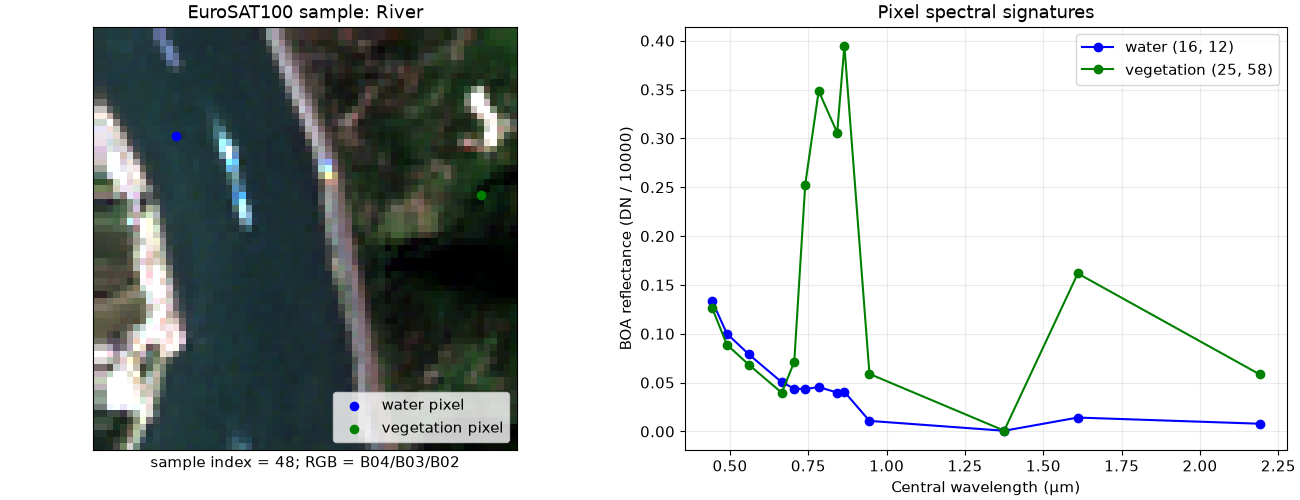

Dataset samples in this split: 60
Selected class: River
Image shape: (13, 64, 64) = (bands, height, width)
Available bands: ('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A')


In [15]:
from pathlib import Path
from torchgeo.datasets import EuroSAT100

# The dataset is downloaded only if it is not already available locally.
dataset_root = Path("data") / "eurosat100"
bands = EuroSAT100.all_band_names
eurosat_train = EuroSAT100(
    root=dataset_root,
    split="train",
    bands=bands,
    download=True,
    checksum=True,
)

# Prefer a water or vegetation scene so the first example is easy to interpret.
preferred_classes = ("River", "SeaLake", "Forest", "HerbaceousVegetation")
selected_sample = None
selected_index = None
selected_class = None
for desired_class in preferred_classes:
    for sample_index in range(len(eurosat_train)):
        candidate = eurosat_train[sample_index]
        candidate_class = eurosat_train.classes[int(candidate["label"])]
        if candidate_class == desired_class:
            selected_sample = candidate
            selected_index = sample_index
            selected_class = candidate_class
            break
    if selected_sample is not None:
        break

image = selected_sample["image"].numpy()
rgb_indices = [eurosat_train.bands.index(band) for band in ("B04", "B03", "B02")]
rgb_image = np.moveaxis(image[rgb_indices], 0, -1)
# EuroSAT stores Sentinel-2 values using the conventional L2A quantification value.
# The dataset does not include Collection-1 BOA_ADD_OFFSET metadata, so use DN / 10000.
reflectance_scale = 10000.0

def stretch_rgb(rgb_reflectance, lower_percentile=2, upper_percentile=98):
    lower = np.percentile(rgb_reflectance, lower_percentile, axis=(0, 1), keepdims=True)
    upper = np.percentile(rgb_reflectance, upper_percentile, axis=(0, 1), keepdims=True)
    scale = np.maximum(upper - lower, 1e-6)
    return np.clip((rgb_reflectance - lower) / scale, 0, 1)

rgb_reflectance = np.clip(rgb_image / reflectance_scale, 0, 1)
rgb_image = stretch_rgb(rgb_reflectance)

# Coordinates are (row, column); both can be changed for exploration.
water_pixel = (16, 12)
vegetation_pixel = (25, 58)
for name, (row, column) in (("water", water_pixel), ("vegetation", vegetation_pixel)):
    if not (0 <= row < image.shape[1] and 0 <= column < image.shape[2]):
        raise ValueError(f"{name} pixel {row, column} is outside the image.")

signature_scale = reflectance_scale
water_signature = image[:, water_pixel[0], water_pixel[1]] / signature_scale
vegetation_signature = image[:, vegetation_pixel[0], vegetation_pixel[1]] / signature_scale

# Sentinel-2 central wavelengths, expressed in microns (µm).
central_wavelengths = {
    "B01": 0.443,
    "B02": 0.490,
    "B03": 0.560,
    "B04": 0.665,
    "B05": 0.705,
    "B06": 0.740,
    "B07": 0.783,
    "B08": 0.842,
    "B8A": 0.865,
    "B09": 0.945,
    "B10": 1.375,
    "B11": 1.610,
    "B12": 2.190,
}
spectral_order = sorted(eurosat_train.bands, key=central_wavelengths.__getitem__)
spectral_indices = [eurosat_train.bands.index(band) for band in spectral_order]
spectral_wavelengths = [central_wavelengths[band] for band in spectral_order]
fig, (ax_rgb, ax_signature) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
ax_rgb.imshow(rgb_image)
ax_rgb.scatter(water_pixel[1], water_pixel[0], color="blue", s=35, label="water pixel")
ax_rgb.scatter(vegetation_pixel[1], vegetation_pixel[0], color="green", s=35, label="vegetation pixel")
ax_rgb.set_title(f"EuroSAT100 sample: {selected_class}")
ax_rgb.set_xlabel(f"sample index = {selected_index}; RGB = B04/B03/B02")
ax_rgb.set_xticks([])
ax_rgb.set_yticks([])
ax_rgb.legend(loc="lower right")
ax_signature.plot(spectral_wavelengths, water_signature[spectral_indices], marker="o", color="blue", label=f"water {water_pixel}")
ax_signature.plot(spectral_wavelengths, vegetation_signature[spectral_indices], marker="o", color="green", label=f"vegetation {vegetation_pixel}")
ax_signature.set_title("Pixel spectral signatures")
ax_signature.set_xlabel("Central wavelength (µm)")
ax_signature.set_ylabel("BOA reflectance (DN / 10000)")
ax_signature.grid(alpha=0.25)
ax_signature.legend()
plt.show()

print(f"Dataset samples in this split: {len(eurosat_train)}")
print(f"Selected class: {selected_class}")
print(f"Image shape: {image.shape} = (bands, height, width)")
print(f"Available bands: {eurosat_train.bands}")

![Sentinel-2 spectral bands](../assets/sentinel_2_channels-1024x273.png)

This diagram shows the Sentinel-2 bands positioned by wavelength over the atmospheric transmission spectrum. B02–B04 cover the visible range, B05–B07 and B8A sample the red-edge and near-infrared region, and B11–B12 cover the short-wave infrared. B01, B09, and B10 target additional spectral regions, while the thermal-infrared range is shown for context.

*Image source: [Freie Universität Berlin — Sentinel 2](https://blogs.fu-berlin.de/reseda/sentinel-2/).*

### 5.2 Selecting training and testing scenes

Before introducing NDVI, we define the two-scene experiment. `River_458.tif` is the only training scene and `River_923.tif` is the only testing scene. We use the complete set of pixels from the first image to train the neurons, then apply them to every pixel of the second image. No additional image is used.

The RGB views below establish the visual context before we move to the spectral index. The scenes are stored as 13-band tensors, but RGB uses only B04, B03, and B02.

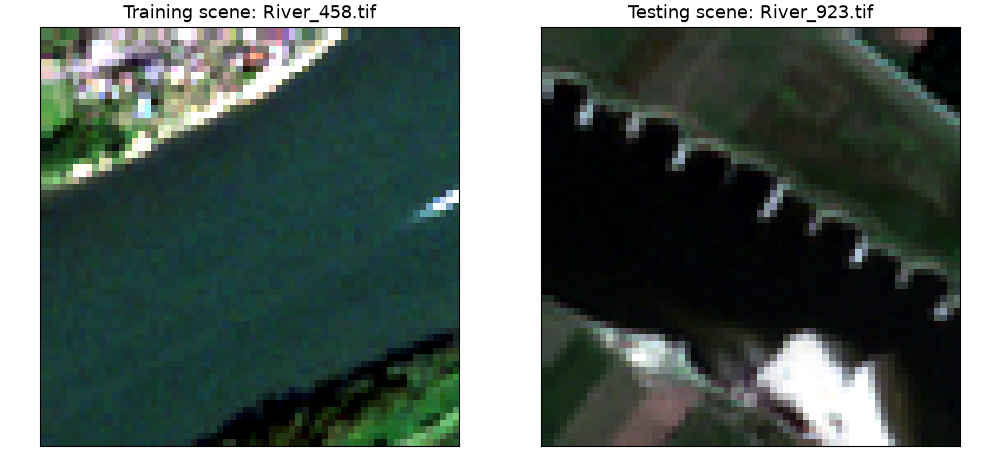

Training image shape: (13, 64, 64)
Testing image shape: (13, 64, 64)
Bands available to each pixel: ('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A')


In [16]:
from pathlib import Path
from torchgeo.datasets import EuroSAT100

# Load the two split indexes, but read only the selected training and test images.
remote_sensing_root = Path("data") / "eurosat100"
all_bands = EuroSAT100.all_band_names
train_dataset = EuroSAT100(
    root=remote_sensing_root,
    split="train",
    bands=all_bands,
    download=True,
    checksum=True,
)
test_dataset = EuroSAT100(
    root=remote_sensing_root,
    split="test",
    bands=all_bands,
    download=True,
    checksum=True,
)

train_filename = "River_458.tif"
test_filename = "River_923.tif"

def find_sample_index(dataset, filename):
    for index, (path, _) in enumerate(dataset.samples):
        if Path(path).name == filename:
            return index
    raise ValueError(f"Could not find {filename} in the {dataset.split} split.")

train_index = find_sample_index(train_dataset, train_filename)
test_index = find_sample_index(test_dataset, test_filename)
train_image = train_dataset[train_index]["image"].numpy().astype(float)
test_image = test_dataset[test_index]["image"].numpy().astype(float)

rgb_indices = [all_bands.index(band) for band in ("B04", "B03", "B02")]
train_rgb = np.moveaxis(train_image[rgb_indices], 0, -1)
test_rgb = np.moveaxis(test_image[rgb_indices], 0, -1)
train_rgb = stretch_rgb(np.clip(train_rgb / reflectance_scale, 0, 1))
test_rgb = stretch_rgb(np.clip(test_rgb / reflectance_scale, 0, 1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
axes[0].imshow(train_rgb)
axes[0].set_title(f"Training scene: {train_filename}")
axes[1].imshow(test_rgb)
axes[1].set_title(f"Testing scene: {test_filename}")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

print(f"Training image shape: {train_image.shape}")
print(f"Testing image shape: {test_image.shape}")
print(f"Bands available to each pixel: {all_bands}")

### 5.3 NDVI and vegetation targets

The Normalized Difference Vegetation Index (NDVI) is computed from two bands of the spectral signature:

$$
\operatorname{NDVI}=\frac{\rho_{\mathrm{NIR}}-\rho_{\mathrm{Red}}}{\rho_{\mathrm{NIR}}+\rho_{\mathrm{Red}}}.
$$

For Sentinel-2, we use B08 as the near-infrared band and B04 as the red band. Healthy green vegetation absorbs red radiation because of chlorophyll and reflects much more near-infrared radiation because of its leaf structure. This contrast appears directly in the spectral signature, so a normalized difference between the two reflectances provides a useful vegetation indicator. NDVI is a proxy, not a perfect vegetation measurement: soil, water, shadows, clouds, and mixed pixels can produce ambiguous values.

The binary vegetation target is also defined here, so the NDVI theory and thresholding remain together. The threshold is customizable; `0.30` is only a starting point for this exercise.

**Open question:** Which structures in the RGB image would be difficult to distinguish without the near-infrared band?

In [17]:
red_index = all_bands.index("B04")
nir_index = all_bands.index("B08")

def compute_ndvi(image):
    red = image[red_index]
    nir = image[nir_index]
    denominator = nir + red
    # Avoid division by zero while preserving the image shape.
    return np.divide(
        nir - red,
        denominator,
        out=np.zeros_like(denominator, dtype=float),
        where=denominator != 0,
    )

train_ndvi = compute_ndvi(train_image)
test_ndvi = compute_ndvi(test_image)

# Change this parameter to make the vegetation definition more or less conservative.
vegetation_threshold = 0.30
train_vegetation = (train_ndvi >= vegetation_threshold).astype(float)
test_vegetation = (test_ndvi >= vegetation_threshold).astype(float)

derived_root = remote_sensing_root / "derived"
derived_root.mkdir(parents=True, exist_ok=True)
np.save(derived_root / "River_458_ndvi.npy", train_ndvi)
np.save(derived_root / "River_923_ndvi.npy", test_ndvi)

print(f"Saved NDVI arrays to: {derived_root}")
print(f"Training NDVI range: [{train_ndvi.min():.3f}, {train_ndvi.max():.3f}]")
print(f"Testing NDVI range: [{test_ndvi.min():.3f}, {test_ndvi.max():.3f}]")
print(f"Training vegetation fraction: {train_vegetation.mean():.1%}")
print(f"Testing vegetation fraction: {test_vegetation.mean():.1%}")

Saved NDVI arrays to: data/eurosat100/derived
Training NDVI range: [-0.244, 0.796]
Testing NDVI range: [-0.205, 0.773]
Training vegetation fraction: 20.3%
Testing vegetation fraction: 46.1%


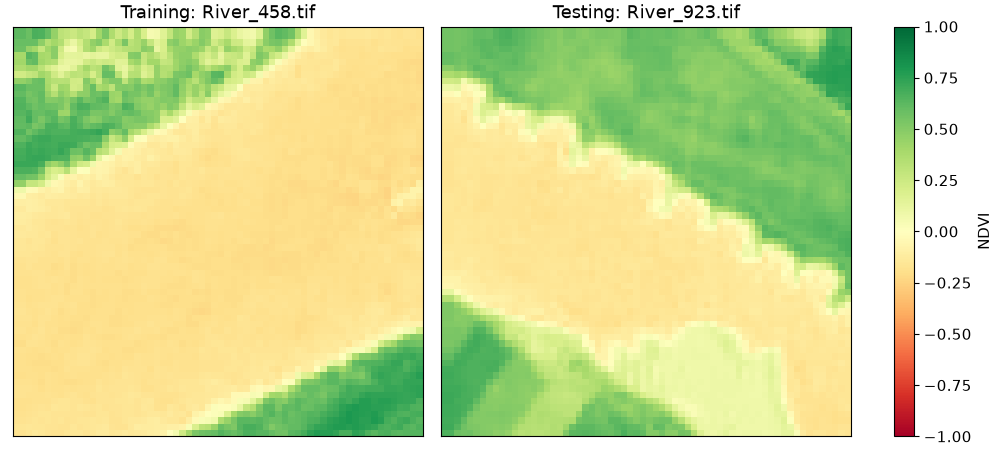

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
ndvi_image = axes[0].imshow(train_ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title(f"Training: {train_filename}")
axes[1].imshow(test_ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title(f"Testing: {test_filename}")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(ndvi_image, ax=axes, label="NDVI")
plt.show()

#### 5.3.1 NDVI histograms

The maps show where NDVI values occur; these histograms show how frequently they occur in each scene. The two distributions use separate axes so that the training and testing scenes can be inspected independently. The vertical line marks the current vegetation threshold.

**Open question:** Do the two scenes have similar NDVI distributions, and what might a distribution shift mean for the test performance of the neurons?

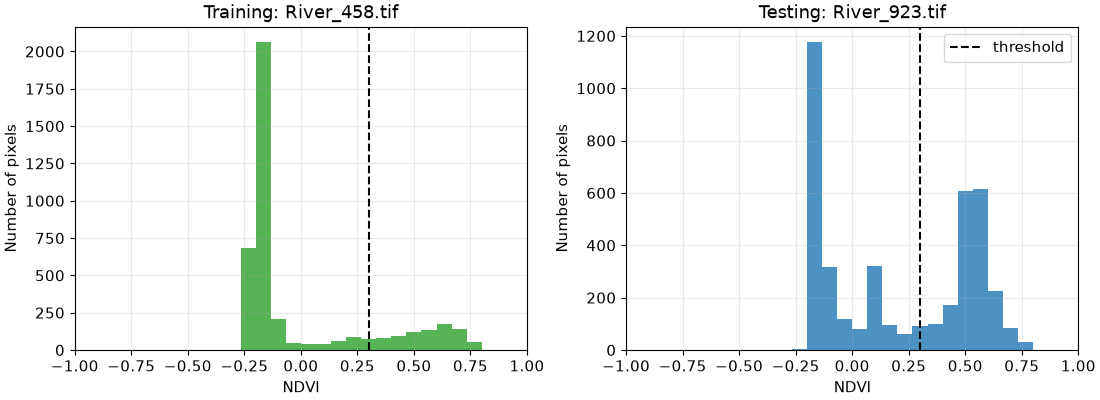

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].hist(train_ndvi.ravel(), bins=30, range=(-1, 1), color="tab:green", alpha=0.8)
axes[0].axvline(vegetation_threshold, color="black", linestyle="--")
axes[0].set_title(f"Training: {train_filename}")
axes[1].hist(test_ndvi.ravel(), bins=30, range=(-1, 1), color="tab:blue", alpha=0.8)
axes[1].axvline(vegetation_threshold, color="black", linestyle="--", label="threshold")
axes[1].set_title(f"Testing: {test_filename}")
for ax in axes:
    ax.set_xlabel("NDVI")
    ax.set_ylabel("Number of pixels")
    ax.set_xlim(-1, 1)
    ax.grid(alpha=0.25)
axes[1].legend()
plt.show()

#### 5.3.2 Vegetation masks from a threshold

A threshold converts the continuous NDVI target into a binary map:

$$
m(x)=\begin{cases}1 & \text{if NDVI}(x)\geq \tau,\\0 & \text{otherwise.}
\end{cases}
$$

The parameter `vegetation_threshold` controls the trade-off. Increasing it produces a more conservative vegetation map; decreasing it includes more pixels but may classify soil, water, or shadow as vegetation. Inspect both scenes and compare the mask with the RGB appearance.

**Open question:** How would the vegetation mask change if the threshold were changed from `0.30` to `0.20` or `0.50`?

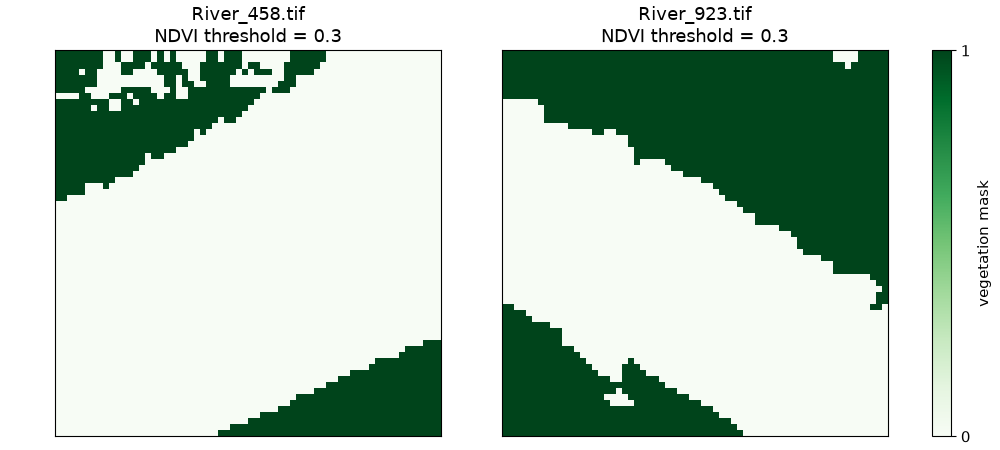

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, mask, filename in zip(axes, (train_vegetation, test_vegetation), (train_filename, test_filename)):
    image = ax.imshow(mask, cmap="Greens", vmin=0, vmax=1)
    ax.set_title(f"{filename}\nNDVI threshold = {vegetation_threshold}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(image, ax=axes, ticks=[0, 1], label="vegetation mask")
plt.show()

### 5.4 Two single-neuron models

Every pixel is one training example with a 13-dimensional spectral input. The inputs are standardized using training-scene statistics, and both models are trained only on the training scene before being applied to the unseen test scene.

#### Regression neuron

| Component | Architecture |
| --- | --- |
| Input | 13 standardized Sentinel-2 spectral features, $x \in \mathbb{R}^{13}$ |
| Linear layer | One neuron with 13 weights and one bias: $z = x^T w + b$ |
| Activation | Identity: $\hat{y}=z$ |
| Target | Continuous NDVI computed from B04 and B08 |
| Loss | Half mean squared error: $L=\frac{1}{2N}\sum_i(\hat{y}_i-y_i)^2$ |
| Optimization | Full-batch gradient descent; learning rate = 0.05; epochs = 1200 |

#### Classification neuron

| Component | Architecture |
| --- | --- |
| Input | 13 standardized Sentinel-2 spectral features, $x \in \mathbb{R}^{13}$ |
| Linear layer | One neuron with 13 weights and one bias: $z = x^T w + b$ |
| Activation | Sigmoid probability: $p=\sigma(z)=1/(1+e^{-z})$ |
| Target | Binary vegetation map: 1 when NDVI $\geq$ 0.30, otherwise 0 |
| Loss | Binary cross-entropy: $L=-\frac{1}{N}\sum_i[y_i\log(p_i)+(1-y_i)\log(1-p_i)]$ |
| Optimization | Full-batch gradient descent; learning rate = 0.10; epochs = 1200; prediction threshold = 0.5 |

This is a deliberately small demonstration: neighboring pixels are not statistically independent, and NDVI itself is a deterministic function of two input bands. The purpose is to show how the same single-neuron structure changes when the activation, target, and loss change.

#### 5.4.1 Training the regression and classification neurons

The code below reshapes the training image from `(bands, height, width)` into one row per pixel. The 13 spectral values are standardized using training-scene statistics only, and the same transformation is applied to the test scene.

The regression neuron minimizes half the mean squared error. The classification neuron minimizes binary cross-entropy. In both cases, gradient descent updates the same kinds of parameters—weights and a bias—but the output activation and loss determine the gradient.

In [21]:
# Arrange each pixel as one row and keep the 13 spectral bands as features.
x_train_raw = np.moveaxis(train_image, 0, -1).reshape(-1, len(all_bands)) / reflectance_scale
x_test_raw = np.moveaxis(test_image, 0, -1).reshape(-1, len(all_bands)) / reflectance_scale
y_train_regression = train_ndvi.reshape(-1)
y_test_regression = test_ndvi.reshape(-1)
y_train_classification = train_vegetation.reshape(-1)
y_test_classification = test_vegetation.reshape(-1)

# Standardization is fitted on the training image and reused unchanged for testing.
spectral_mean = x_train_raw.mean(axis=0)
spectral_std = np.where(x_train_raw.std(axis=0) < 1e-8, 1.0, x_train_raw.std(axis=0))
x_train = (x_train_raw - spectral_mean) / spectral_std
x_test = (x_test_raw - spectral_mean) / spectral_std

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -60, 60)))

def binary_cross_entropy(probabilities, targets):
    probabilities = np.clip(probabilities, 1e-12, 1.0 - 1e-12)
    return -np.mean(
        targets * np.log(probabilities)
        + (1.0 - targets) * np.log(1.0 - probabilities)
    )

def half_mse(predictions, targets):
    return 0.5 * np.mean((predictions - targets) ** 2)

# Regression neuron: identity activation and a continuous NDVI target.
regression_weights = np.zeros(x_train.shape[1])
regression_bias = y_train_regression.mean()
regression_learning_rate = 0.05
regression_epochs = 1200
regression_loss_history = []

for _ in range(regression_epochs):
    regression_output = x_train @ regression_weights + regression_bias
    regression_error = regression_output - y_train_regression
    regression_loss_history.append(half_mse(regression_output, y_train_regression))

    # For an identity neuron with half-MSE, dL/dz = prediction - target.
    regression_weights -= regression_learning_rate * (x_train.T @ regression_error) / len(x_train)
    regression_bias -= regression_learning_rate * regression_error.mean()

# Classification neuron: sigmoid activation and a binary vegetation target.
classification_weights = np.zeros(x_train.shape[1])
classification_bias = 0.0
classification_learning_rate = 0.10
classification_epochs = 1200
classification_loss_history = []

for _ in range(classification_epochs):
    classification_logits = x_train @ classification_weights + classification_bias
    classification_probabilities = sigmoid(classification_logits)
    classification_loss_history.append(
        binary_cross_entropy(classification_probabilities, y_train_classification)
    )

    # For sigmoid plus binary cross-entropy, dL/dz = probability - target.
    classification_error = classification_probabilities - y_train_classification
    classification_weights -= classification_learning_rate * (x_train.T @ classification_error) / len(x_train)
    classification_bias -= classification_learning_rate * classification_error.mean()

test_ndvi_prediction = x_test @ regression_weights + regression_bias
test_vegetation_probability = sigmoid(x_test @ classification_weights + classification_bias)
test_vegetation_prediction = (test_vegetation_probability >= 0.5).astype(float)

print(f"Final regression training loss: {regression_loss_history[-1]:.5f}")
print(f"Final classification training loss: {classification_loss_history[-1]:.5f}")
print(f"Test NDVI RMSE: {np.sqrt(np.mean((test_ndvi_prediction - y_test_regression) ** 2)):.3f}")
print(f"Test vegetation accuracy: {np.mean(test_vegetation_prediction == y_test_classification):.1%}")

Final regression training loss: 0.00147
Final classification training loss: 0.03941
Test NDVI RMSE: 0.195
Test vegetation accuracy: 94.4%


#### 5.4.2 Loss curves after training

These curves show how the two objectives changed during optimization. Compare their scale and shape, and check whether the loss decreases smoothly or whether the learning rate causes oscillations. You can change the learning rates and epoch counts above and rerun this cell.

**Open question:** Why can two models trained on the same spectral inputs have loss curves with different numerical values and convergence behavior?

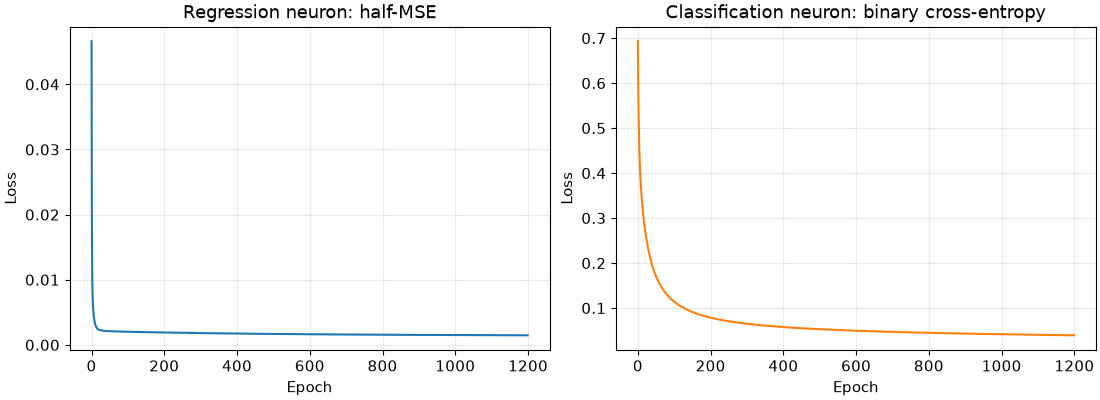

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(regression_loss_history, color="tab:blue")
axes[0].set_title("Regression neuron: half-MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[1].plot(classification_loss_history, color="tab:orange")
axes[1].set_title("Classification neuron: binary cross-entropy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.25)
plt.show()

#### 5.4.3 Regression prediction maps

These three maps compare the true NDVI, the regression neuron's prediction, and the prediction error for the unseen test scene. The first two maps share the NDVI color scale; the error map uses a diverging scale so that underestimation and overestimation have different colors.

**Open question:** Where are the largest errors located, and do they correspond to boundaries or mixed pixels?

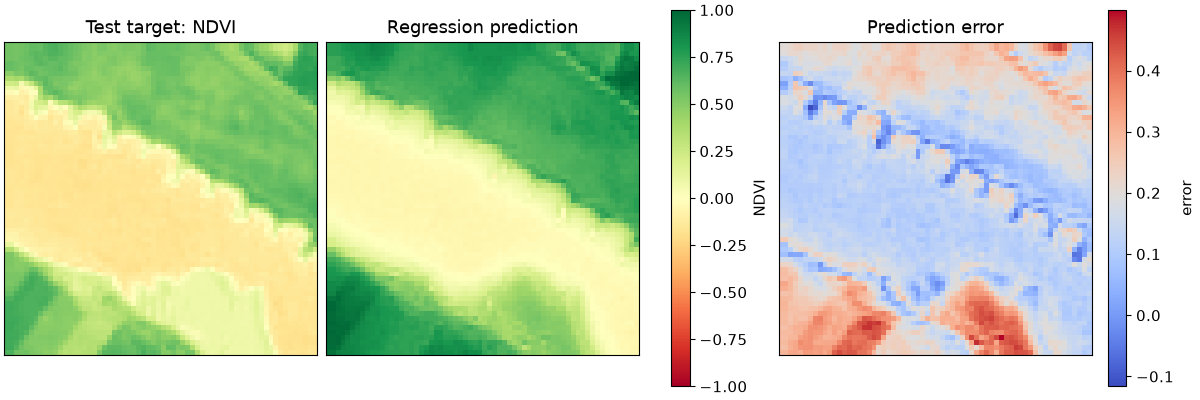

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
target_image = axes[0].imshow(test_ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("Test target: NDVI")
prediction_image = axes[1].imshow(test_ndvi_prediction.reshape(test_ndvi.shape), cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title("Regression prediction")
regression_error_map = test_ndvi_prediction.reshape(test_ndvi.shape) - test_ndvi
error_image = axes[2].imshow(regression_error_map, cmap="coolwarm")
axes[2].set_title("Prediction error")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(target_image, ax=axes[:2], label="NDVI")
fig.colorbar(error_image, ax=axes[2], label="error")
plt.show()

#### 5.4.4 Regression diagnostic

This scatter plot compares the predicted and true NDVI value for every pixel in the test scene. The dashed diagonal represents perfect prediction; points near it indicate smaller errors.

**Open question:** Does the regression neuron behave differently for low-NDVI and high-NDVI pixels?

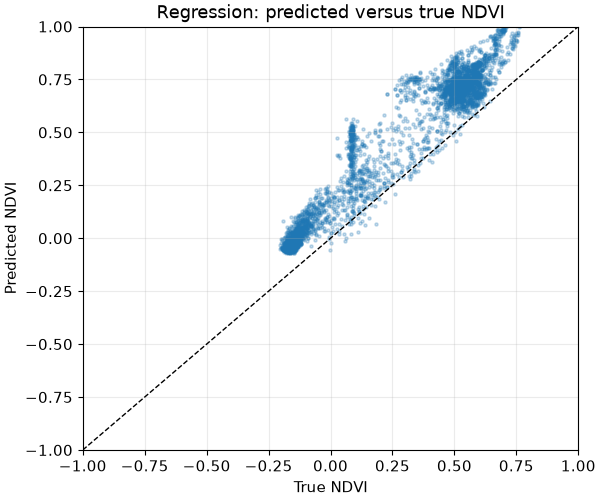

In [24]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(y_test_regression, test_ndvi_prediction, s=5, alpha=0.25)
ax.plot([-1, 1], [-1, 1], "k--", linewidth=1)
ax.set_title("Regression: predicted versus true NDVI")
ax.set_xlabel("True NDVI")
ax.set_ylabel("Predicted NDVI")
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.grid(alpha=0.25)
plt.show()

#### 5.4.5 Classification prediction maps

These maps compare the thresholded target, the sigmoid probability, and the final binary prediction for the test scene. The probability map is continuous, while the target and prediction maps contain only two classes.

**Open question:** Which pixels have uncertain probabilities, and do they occur near the boundary between water, soil, and vegetation?

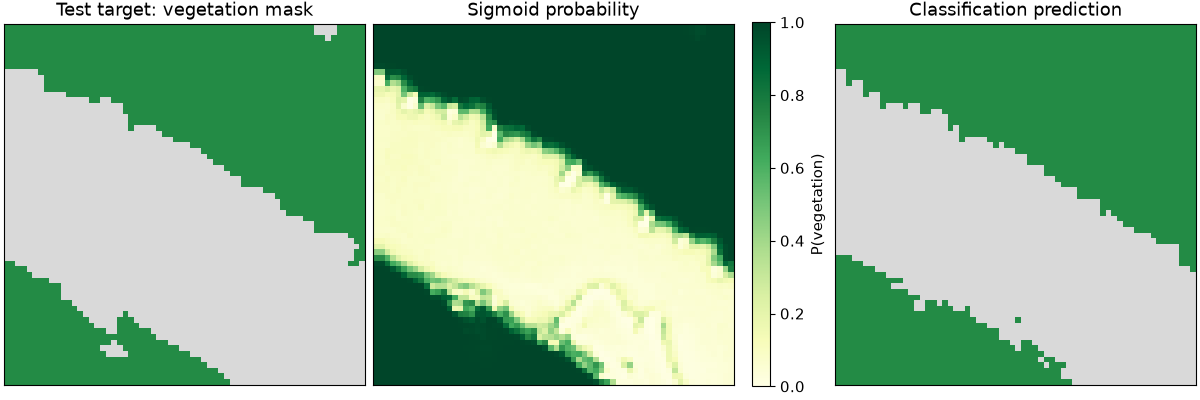

In [25]:
from matplotlib.colors import ListedColormap

mask_cmap = ListedColormap(["#d9d9d9", "#238b45"])
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
axes[0].imshow(test_vegetation, cmap=mask_cmap, vmin=0, vmax=1)
axes[0].set_title("Test target: vegetation mask")
probability_image = axes[1].imshow(test_vegetation_probability.reshape(test_vegetation.shape), cmap="YlGn", vmin=0, vmax=1)
axes[1].set_title("Sigmoid probability")
axes[2].imshow(test_vegetation_prediction.reshape(test_vegetation.shape), cmap=mask_cmap, vmin=0, vmax=1)
axes[2].set_title("Classification prediction")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(probability_image, ax=axes[1], label="P(vegetation)")
plt.show()

#### 5.4.6 Classification confusion matrix

The confusion matrix counts the four possible outcomes of the binary vegetation prediction. Rows are the threshold-derived target classes and columns are the neuron's predicted classes.

**Open question:** Which type of error is more important for a vegetation map: missing vegetation or falsely labeling non-vegetated pixels as vegetation?

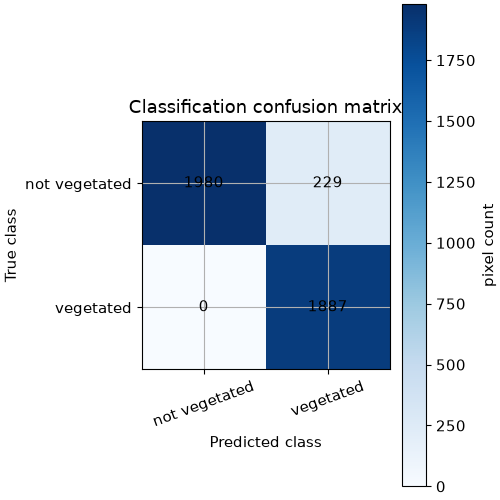

In [26]:
classification_confusion = np.array([
    [
        np.sum((y_test_classification == 0) & (test_vegetation_prediction == 0)),
        np.sum((y_test_classification == 0) & (test_vegetation_prediction == 1)),
    ],
    [
        np.sum((y_test_classification == 1) & (test_vegetation_prediction == 0)),
        np.sum((y_test_classification == 1) & (test_vegetation_prediction == 1)),
    ],
])

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
image = ax.imshow(classification_confusion, cmap="Blues")
ax.set_title("Classification confusion matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks([0, 1], ["not vegetated", "vegetated"], rotation=20)
ax.set_yticks([0, 1], ["not vegetated", "vegetated"])
for row in range(2):
    for column in range(2):
        ax.text(column, row, classification_confusion[row, column], ha="center", va="center")
fig.colorbar(image, ax=ax, label="pixel count")
plt.show()

### 5.5 Interpretation

The two neurons use exactly the same pixel-level input representation but solve different tasks. The regression neuron predicts a continuous index, so its errors can be positive or negative and are summarized naturally with an RMSE. The classification neuron predicts a probability and then applies a threshold, so its errors are summarized with a confusion matrix.

Because the training set contains only one image, these results should be interpreted as a controlled demonstration rather than a robust land-cover model. A larger study would require multiple scenes, independent geographic test areas, cloud and quality masks, and possibly a convolutional model that preserves spatial context.

## 6. Summary and discussion

Suggested time: 5 minutes.

Use the following statements to open the discussion:

- A trainable model turns a data-analysis problem into the optimization of a parameterized function.
- Linear regression, a neuron with identity activation, and least squares describe the same basic affine model from different perspectives.
- Gradient descent is a general computational strategy, while the loss and activation determine what the model is encouraged to learn.
- An NDVI threshold creates a useful target map, but it is still an assumption rather than independent ground truth.
- A pixel-wise neuron can use spectral information but cannot represent spatial context by itself.

**Discussion prompts:** Which assumptions were made in the remote-sensing example? What would need to change for a reliable map over a new geographic region?